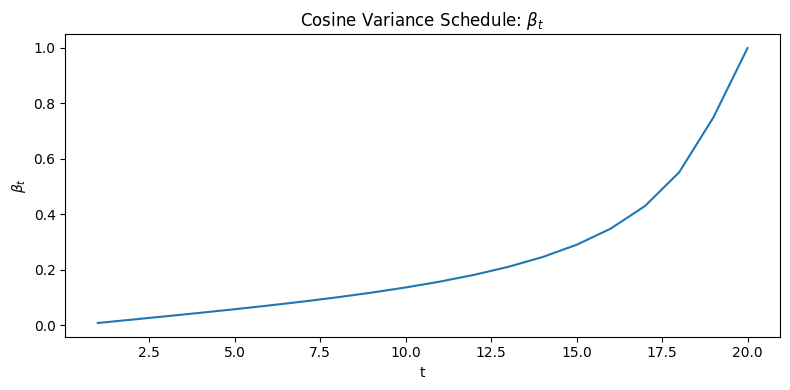

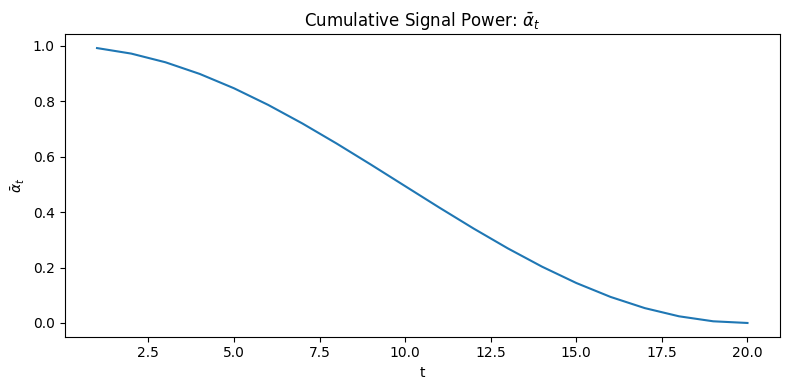

In [1]:
import math
import torch
import matplotlib.pyplot as plt

def cosine_variance_schedule(s, epsilon=0.008):
    # same structure as your code
    steps = torch.linspace(0, s, steps=s+1, dtype=torch.float32)
    f_t = torch.cos(((steps / s + epsilon) / (1.0 + epsilon)) * math.pi * 0.5) ** 2
    betas = torch.clip(1.0 - f_t[1:] / f_t[:s], 0.0, 0.999)
    return betas

if __name__ == "__main__":
    s = 20  # number of diffusion steps

    betas = cosine_variance_schedule(s, epsilon=0.008)
    alphas = 1.0 - betas
    alpha_bar = torch.cumprod(alphas, dim=0)

    # Plot beta_t
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, s+1), betas.numpy())
    plt.title("Cosine Variance Schedule: $\\beta_t$")
    plt.xlabel("t")
    plt.ylabel("$\\beta_t$")
    plt.tight_layout()

    # Plot alpha_bar_t
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, s+1), alpha_bar.numpy())
    plt.title("Cumulative Signal Power: $\\bar{\\alpha}_t$")
    plt.xlabel("t")
    plt.ylabel("$\\bar{\\alpha}_t$")
    plt.tight_layout()

    plt.show()


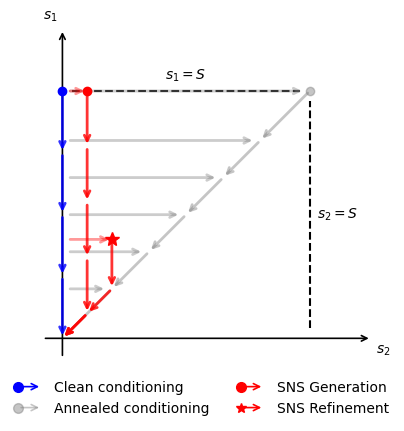

In [8]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.legend_handler import HandlerBase

# =========================
# USER CONTROLS (edit here)
# =========================

# Arrow thickness (ONLY plot arrows, not axes)
CLEAN_LW   = 2
ANNEAL_LW  = 2
SNS_LW     = 2

# Arrow transparency (main trajectories)
CLEAN_ALPHA  = 0.8
ANNEAL_ALPHA = 0.45
SNS_ALPHA    = 0.8

# Horizontal-arrow transparencies (MORE transparent than main trajectories)
ANNEAL_H_ALPHA = 0.4   # gray horizontal arrows
SNS_H1_ALPHA   = 0.4   # red horizontal arrow to SNS Generation start
SNS_H2_ALPHA   = 0.4   # red horizontal arrow to SNS Refinement start (different)

# Arrow z-order (higher = on top)
CLEAN_Z  = 6
ANNEAL_Z = 4
SNS_Z    = 8

# =========================


# --- Custom legend handler: start marker + true arrow ---
class HandlerMarkerArrow(HandlerBase):
    def __init__(self, arrowstyle='->', lw=1.2, marker='o', **kwargs):
        super().__init__(**kwargs)
        self.arrowstyle = arrowstyle
        self.lw = lw
        self.marker = marker

    def create_artists(self, legend, orig_handle, xdescent, ydescent,
                       width, height, fontsize, trans):
        color = orig_handle.get_edgecolor()

        y = ydescent + height / 2.0
        x0 = xdescent + 0.10 * width
        x1 = xdescent + 0.95 * width

        arrow = FancyArrowPatch(
            (x0, y), (x1, y),
            arrowstyle=self.arrowstyle,
            mutation_scale=fontsize * 1.1,
            linewidth=self.lw,
            color=color,
            transform=trans
        )

        marker = plt.Line2D(
            [x0], [y],
            marker=self.marker,
            markersize=fontsize * 0.7,
            color=color,
            linestyle='None',
            transform=trans
        )

        return [arrow, marker]


def segmented_arrow(ax, p0, p1, n=4, zorder=None, **arrowprops):
    """
    Draw a straight path from p0->p1 as n small arrows.
    """
    x0, y0 = p0
    x1, y1 = p1
    for i in range(n):
        xa = x0 + (x1 - x0) * (i / n)
        ya = y0 + (y1 - y0) * (i / n)
        xb = x0 + (x1 - x0) * ((i + 1) / n)
        yb = y0 + (y1 - y0) * ((i + 1) / n)
        ax.annotate(
            '', xy=(xb, yb), xytext=(xa, ya),
            arrowprops=arrowprops,
            zorder=zorder
        )


fig, ax = plt.subplots()

# Limits
ax.set_xlim(-0.12, 1.25)
ax.set_ylim(-0.12, 1.25)
ax.set_aspect('equal', adjustable='box')

# Hide spines and ticks
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

# Cartesian axes (UNCHANGED)
neg = -0.08
ax.annotate('', xy=(1.25, 0), xytext=(neg, 0),
            arrowprops=dict(arrowstyle='->', linewidth=1.2, color='black'),
            clip_on=False)
ax.annotate('', xy=(0, 1.25), xytext=(0, neg),
            arrowprops=dict(arrowstyle='->', linewidth=1.2, color='black'),
            clip_on=False)

# Axis labels
ax.text(1.27, -0.02, r'$s_2$', ha='left', va='top')
ax.text(-0.02, 1.27, r'$s_1$', ha='right', va='bottom')

# Dashed constraints
eps = 0.04
ax.plot([eps, 1 - eps], [1, 1], '--', color='black')
ax.plot([1, 1], [eps, 1 - eps], '--', color='black')

# Constraint labels
ax.text(0.5, 1.03, r'$s_1 = S$', ha='center', va='bottom')
ax.text(1.03, 0.5, r'$s_2 = S$', ha='left', va='center')

# ---- Clean conditioning (blue): break into smaller arrows ----
ax.plot(0, 1, 'o', color='blue', zorder=CLEAN_Z + 1)
segmented_arrow(
    ax, (0, 1), (0, 0), n=4, zorder=CLEAN_Z,
    arrowstyle='->',
    color='blue',
    linewidth=CLEAN_LW,
    alpha=CLEAN_ALPHA
)

# ---- Annealed conditioning (gray) ----
gray_diag_color = (0.5, 0.5, 0.5, ANNEAL_ALPHA)
gray_h_color    = (0.5, 0.5, 0.5, ANNEAL_H_ALPHA)

# Keep the top-right marker
ax.plot(1, 1, 'o', color=gray_diag_color, zorder=ANNEAL_Z + 1)

# ---- Annealed conditioning: horizontal arrows to y = x ----
anneal_levels = [1.00, 0.80, 0.65, 0.50, 0.35, 0.20]
x_start_pad = 0.02
x_end_pad   = 0.02

for y in anneal_levels:
    x0_h, y0_h = x_start_pad, y
    x1_h, y1_h = max(y - x_end_pad, x0_h + 1e-6), y

    ax.annotate(
        '', xy=(x1_h, y1_h), xytext=(x0_h, y0_h),
        arrowprops=dict(
            arrowstyle='->',
            color=gray_h_color,
            linewidth=ANNEAL_LW
        ),
        zorder=ANNEAL_Z
    )

# ---- Annealed conditioning: break the long diagonal into smaller arrow segments ----
diag_breaks = sorted(set(anneal_levels + [0.0]), reverse=True)
for a, b in zip(diag_breaks[:-1], diag_breaks[1:]):
    ax.annotate(
        '', xy=(b, b), xytext=(a, a),
        arrowprops=dict(
            arrowstyle='->',
            color=gray_diag_color,
            linewidth=ANNEAL_LW
        ),
        zorder=ANNEAL_Z
    )

# ---- SNS Generation (red, circle start) ----
x0, y0 = 0.1, 1.0
x1, y1 = 0.1, 0.1

# Horizontal red arrow from y-axis to SNS Generation start (more transparent)
red_h1_color = (1.0, 0.0, 0.0, SNS_H1_ALPHA)
ax.annotate(
    '', xy=(x0, y0), xytext=(x_start_pad, y0),
    arrowprops=dict(
        arrowstyle='->',
        color=red_h1_color,
        linewidth=SNS_LW
    ),
    zorder=SNS_Z
)

ax.plot(x0, y0, 'o', color='red', zorder=SNS_Z + 1)

# Break the vertical part into smaller arrows
segmented_arrow(
    ax, (x0, y0), (x1, y1), n=4, zorder=SNS_Z,
    arrowstyle='->',
    color='red',
    linewidth=SNS_LW,
    alpha=SNS_ALPHA
)

# Diagonal red line should be ONE arrow (x1,y1) -> (0,0)
ax.annotate(
    '', xy=(0, 0), xytext=(x1, y1),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        linewidth=SNS_LW,
        alpha=SNS_ALPHA
    ),
    zorder=SNS_Z
)

# ---- SNS Refinement (red, STAR start) ----
xr0, yr0 = 0.2, 0.4
xr1, yr1 = 0.2, 0.2

# Horizontal red arrow from y-axis to SNS Refinement start (different transparency)
red_h2_color = (1.0, 0.0, 0.0, SNS_H2_ALPHA)
ax.annotate(
    '', xy=(xr0, yr0), xytext=(x_start_pad, yr0),
    arrowprops=dict(
        arrowstyle='->',
        color=red_h2_color,
        linewidth=SNS_LW
    ),
    zorder=SNS_Z
)

ax.plot(xr0, yr0, marker='*', markersize=10, color='red', zorder=SNS_Z + 2)

# Refinement vertical should be ONE arrow (xr0,yr0) -> (xr1,yr1)
ax.annotate(
    '', xy=(xr1, yr1), xytext=(xr0, yr0),
    arrowprops=dict(
        arrowstyle='->',
        color='red',
        linewidth=SNS_LW,
        alpha=SNS_ALPHA
    ),
    zorder=SNS_Z
)

# Diagonal to origin (keep as segmented small arrows, as before)
segmented_arrow(
    ax, (xr1, yr1), (0, 0), n=2, zorder=SNS_Z + 1,
    arrowstyle='->',
    color='red',
    linewidth=SNS_LW,
    alpha=SNS_ALPHA
)

# ---- Legend (UNCHANGED thickness) ----
blue_handle = FancyArrowPatch((0, 0), (1, 0), color='blue', linewidth=1.2)
gray_handle = FancyArrowPatch((0, 0), (1, 0), color=gray_diag_color, linewidth=1.2)
red_handle  = FancyArrowPatch((0, 0), (1, 0), color='red', linewidth=1.2)
star_handle = FancyArrowPatch((0, 0), (1, 0), color='red', linewidth=1.2)

ax.legend(
    handles=[blue_handle, gray_handle, red_handle, star_handle],
    labels=['Clean conditioning', 'Annealed conditioning',
            'SNS Generation', 'SNS Refinement'],
    handler_map={
        blue_handle: HandlerMarkerArrow(marker='o'),
        gray_handle: HandlerMarkerArrow(marker='o'),
        red_handle:  HandlerMarkerArrow(marker='o'),
        star_handle: HandlerMarkerArrow(marker='*'),
    },
    loc='upper center',
    bbox_to_anchor=(0.5, 0),
    ncol=2,
    frameon=False
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("Phase_space.png", dpi=300)
plt.show()
